In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

In [4]:
df = pd.read_csv("Data/DTWFeatures/dtw_train.csv")

genres = df['label'].unique()
dist_columns = [f'dist_from_{g}' for g in genres]

dist_data = df[dist_columns + ['label']]

dist_data.head()

,dist_from_pop,dist_from_metal,dist_from_disco,dist_from_jazz,dist_from_rock,dist_from_hiphop,dist_from_country,dist_from_reggae,dist_from_blues,dist_from_classical,label
0,0.732880,0.634782,0.628441,0.696880,0.598563,0.649318,0.684026,0.816025,0.897378,0.905234,pop
1,0.733509,0.450161,0.541283,0.564130,0.507069,0.739405,0.549365,0.841685,0.823125,0.680290,metal
2,0.859062,0.579324,0.566396,0.533806,0.572224,0.829276,0.667959,0.681220,0.523605,0.484742,disco
3,0.936977,1.085003,1.082326,1.191202,1.070883,1.018390,1.005502,1.114611,1.285898,1.511855,pop
4,1.120848,0.801959,0.782704,0.706548,0.808161,1.066267,0.943770,0.782993,0.451953,0.289037,jazz


In [5]:
def plot_boxplot(feat_name, ax=None):
    plt.figure(figsize=(9, 6))
    sns.boxplot(data=df, x="label", y=feat_name, ax=ax)
    if ax is None:
        plt.title(f"Boxplot of {feat_name}")

def plot_histplot(feat_name, ax=None):
    plt.figure(figsize=(9, 6))  
    sns.histplot(
        data=df,
        x=feat_name,
        hue="label",
        element="step",
        stat="density",
        common_norm=False,
        ax=ax,
    )
    if ax is None:
        plt.title(f"Histplot of {feat_name}")

def plot_box_hist(feat_name):
    fg, axs = plt.subplots(1, 2, figsize=(18, 8))

    plot_histplot(feat_name, ax=axs[0])
    plot_boxplot(feat_name, ax=axs[1])
   
    fg.subplots_adjust(hspace=0.6, right=0.88)
    fg.suptitle(f"Plots of {feat_name}", fontsize=16, y=0.91)

# EDA

Text(0.5, 1.0, 'Histogram of dist_from_rock for rock and blues songs')

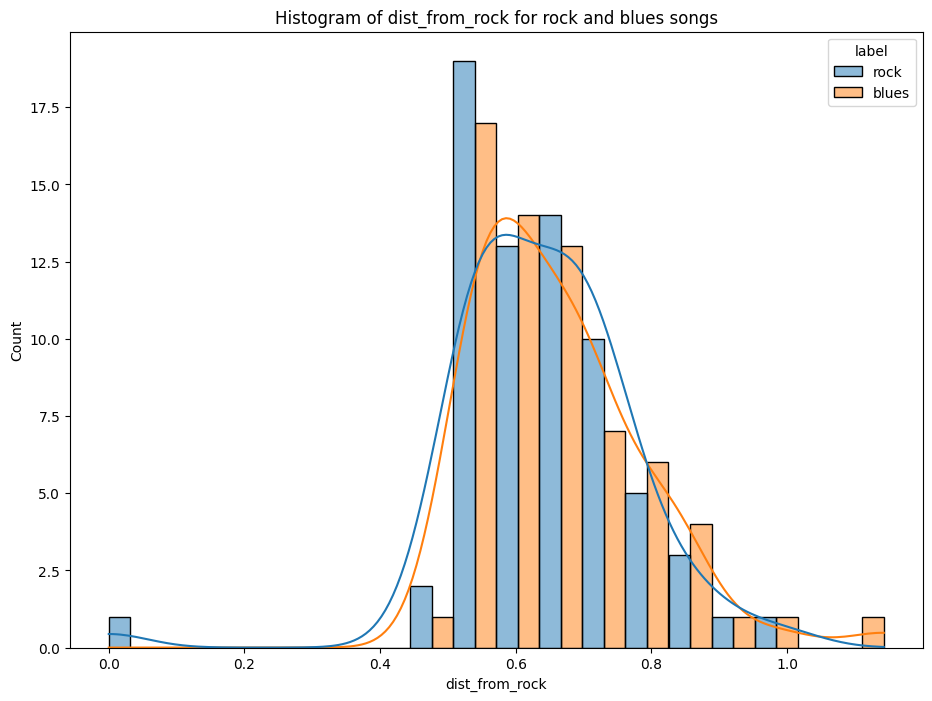

In [17]:
data = dist_data[
    (dist_data['label'] == 'rock') |
    (dist_data['label'] == 'blues')
    ]

plt.figure(figsize=(11, 8))
sns.histplot(data=data, x='dist_from_rock', hue='label', multiple="dodge", kde=True)
plt.title('Histogram of dist_from_rock for rock and blues songs')

Text(0.5, 1.0, 'Histogram of dist_from_classical for classical and metal songs')

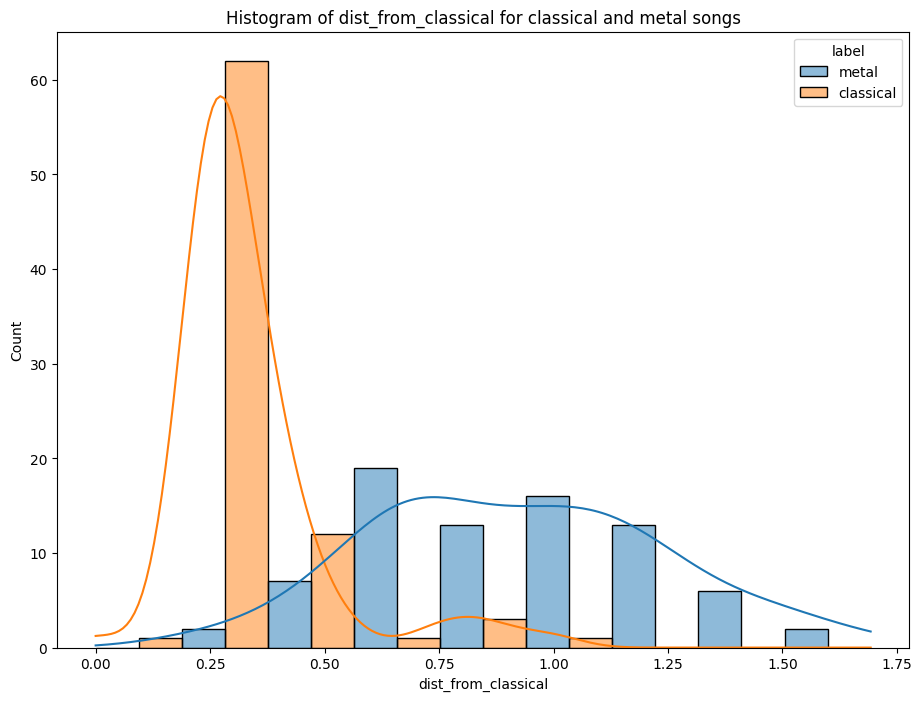

In [18]:
data = dist_data[
    (dist_data['label'] == 'classical') |
    (dist_data['label'] == 'metal')
    ]

plt.figure(figsize=(11, 8))
sns.histplot(data=data, x='dist_from_classical', hue='label', multiple="dodge", kde=True)
plt.title('Histogram of dist_from_classical for classical and metal songs')

In [7]:
X = dist_data.drop('label', axis=1).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

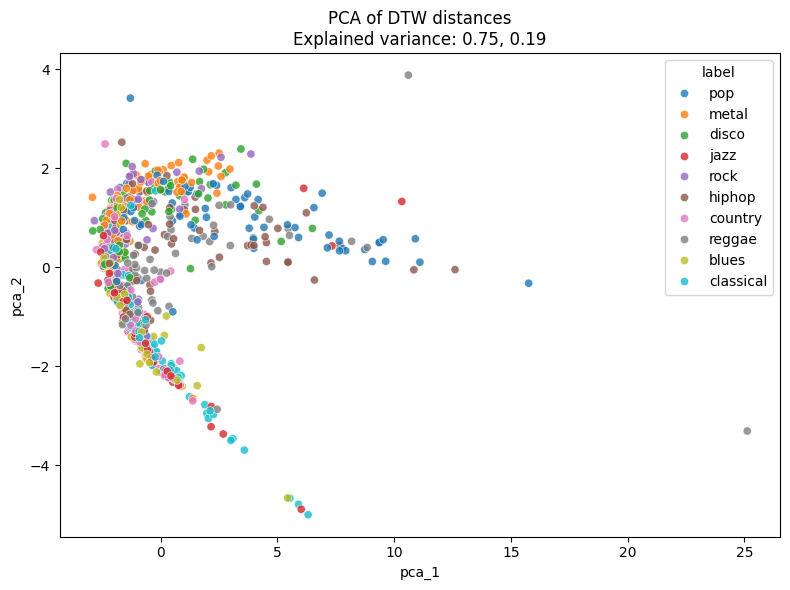

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_data = dist_data.copy()
pca_data["pca_1"] = X_pca[:, 0]
pca_data["pca_2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_data,
    x="pca_1",
    y="pca_2",
    hue="label",
    alpha=0.8
)

plt.title(
    f"PCA of DTW distances\n"
    f"Explained variance: "
    f"{pca.explained_variance_ratio_[0]:.2f}, "
    f"{pca.explained_variance_ratio_[1]:.2f}"
)
plt.tight_layout()
plt.show()

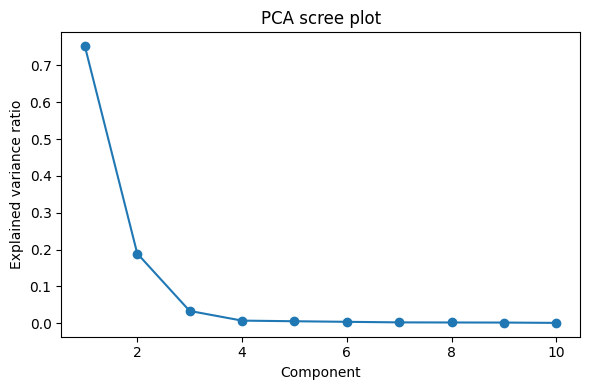

In [9]:
pca_full = PCA().fit(X_scaled)

plt.figure(figsize=(6, 4))
plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("Component")
plt.ylabel("Explained variance ratio")
plt.title("PCA scree plot")
plt.tight_layout()
plt.show()

In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=dist_columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

In [11]:
loadings["PC1"].sort_values(key=np.abs, ascending=False)

dist_from_disco        0.358456
dist_from_rock         0.356525
dist_from_jazz         0.350003
dist_from_metal        0.345605
dist_from_country      0.319288
dist_from_reggae       0.312972
dist_from_hiphop       0.294695
dist_from_blues        0.271038
dist_from_pop          0.268132
dist_from_classical    0.265247
Name: PC1, dtype: float64

In [12]:
loadings["PC2"].sort_values(key=np.abs, ascending=False)

dist_from_classical    0.477668
dist_from_blues        0.472628
dist_from_pop         -0.462375
dist_from_hiphop      -0.353558
dist_from_country     -0.312557
dist_from_reggae       0.266618
dist_from_jazz         0.158206
dist_from_metal       -0.111262
dist_from_rock        -0.055050
dist_from_disco       -0.021123
Name: PC2, dtype: float64

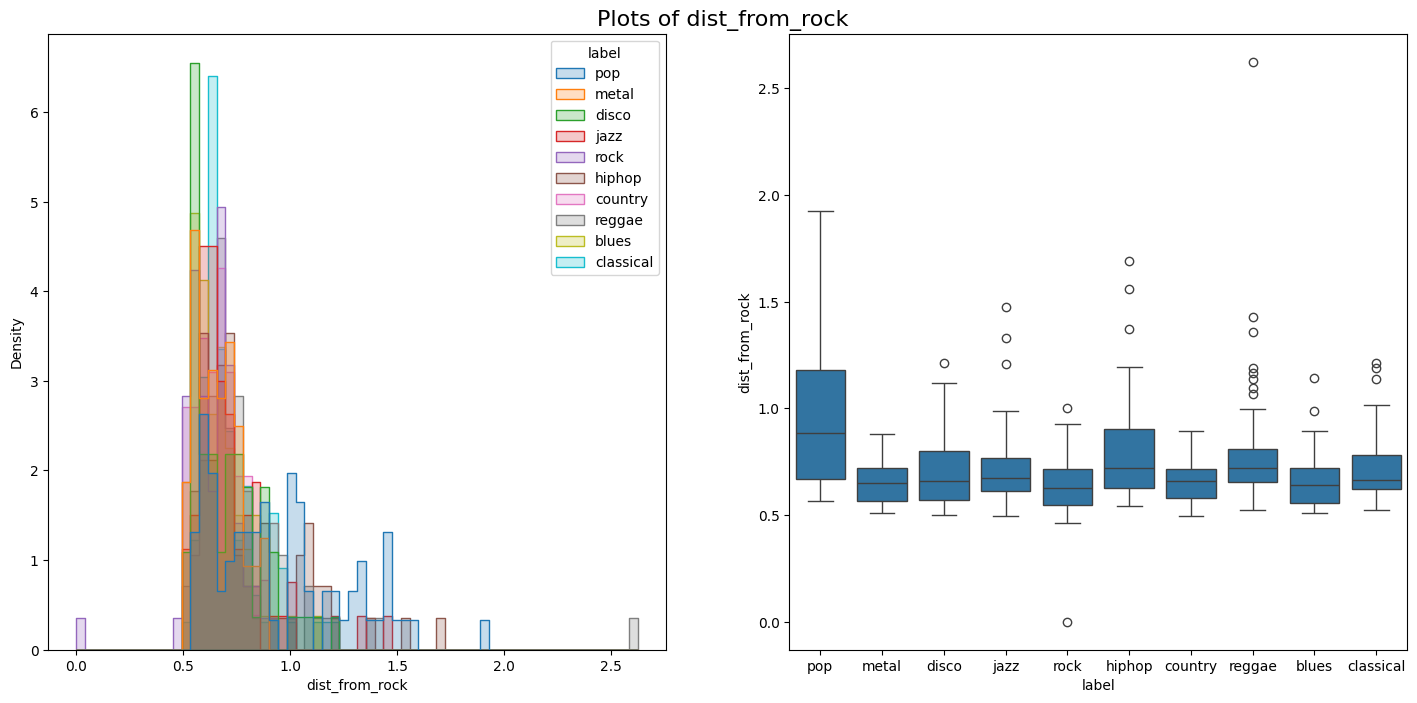

<Figure size 900x600 with 0 Axes>

<Figure size 900x600 with 0 Axes>

In [13]:
plot_box_hist('dist_from_rock')

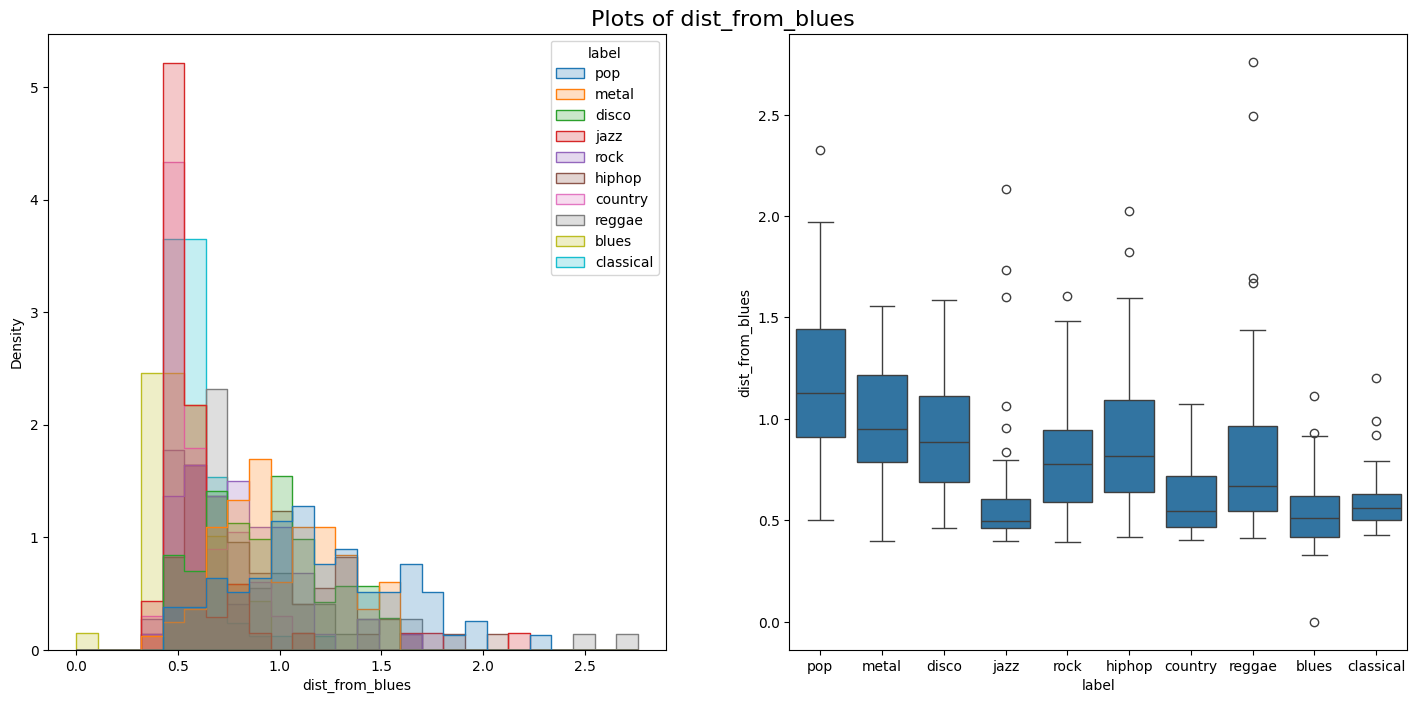

<Figure size 900x600 with 0 Axes>

<Figure size 900x600 with 0 Axes>

In [14]:
plot_box_hist('dist_from_blues')

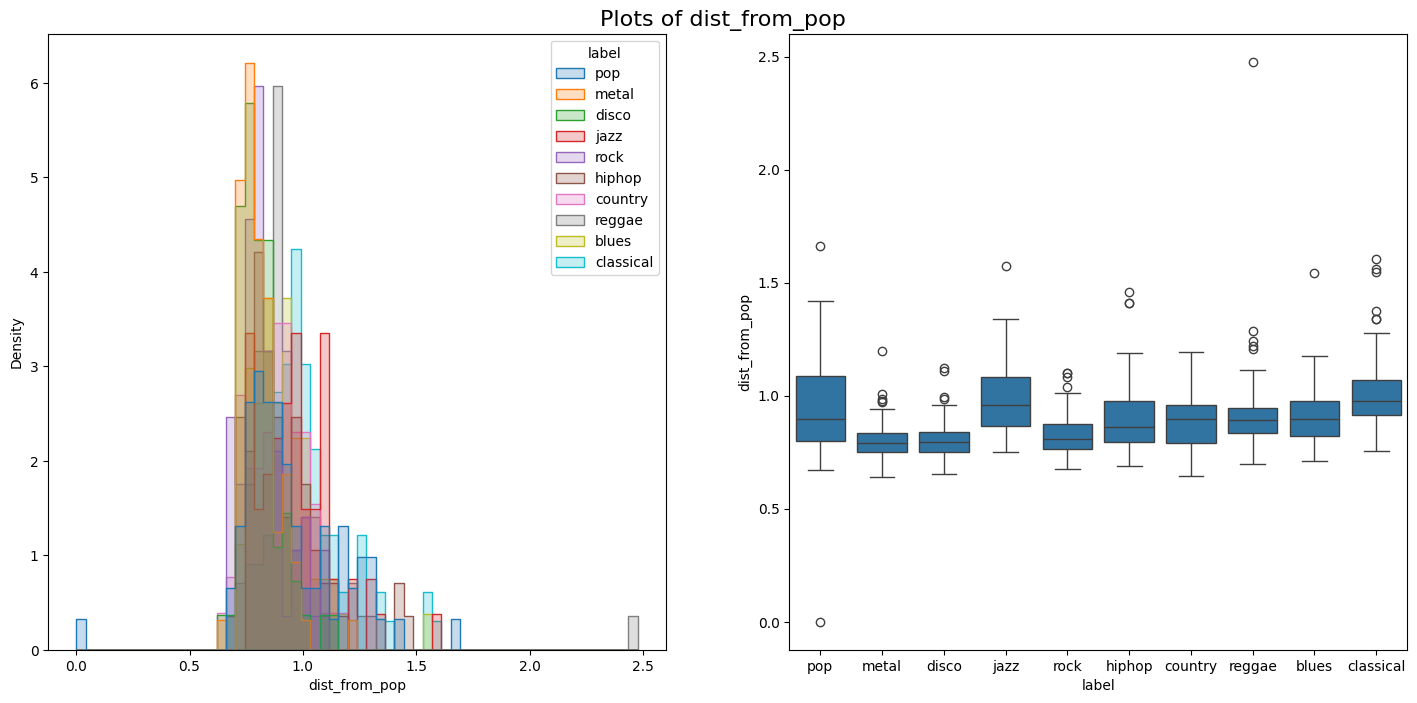

<Figure size 900x600 with 0 Axes>

<Figure size 900x600 with 0 Axes>

In [15]:
plot_box_hist('dist_from_pop')

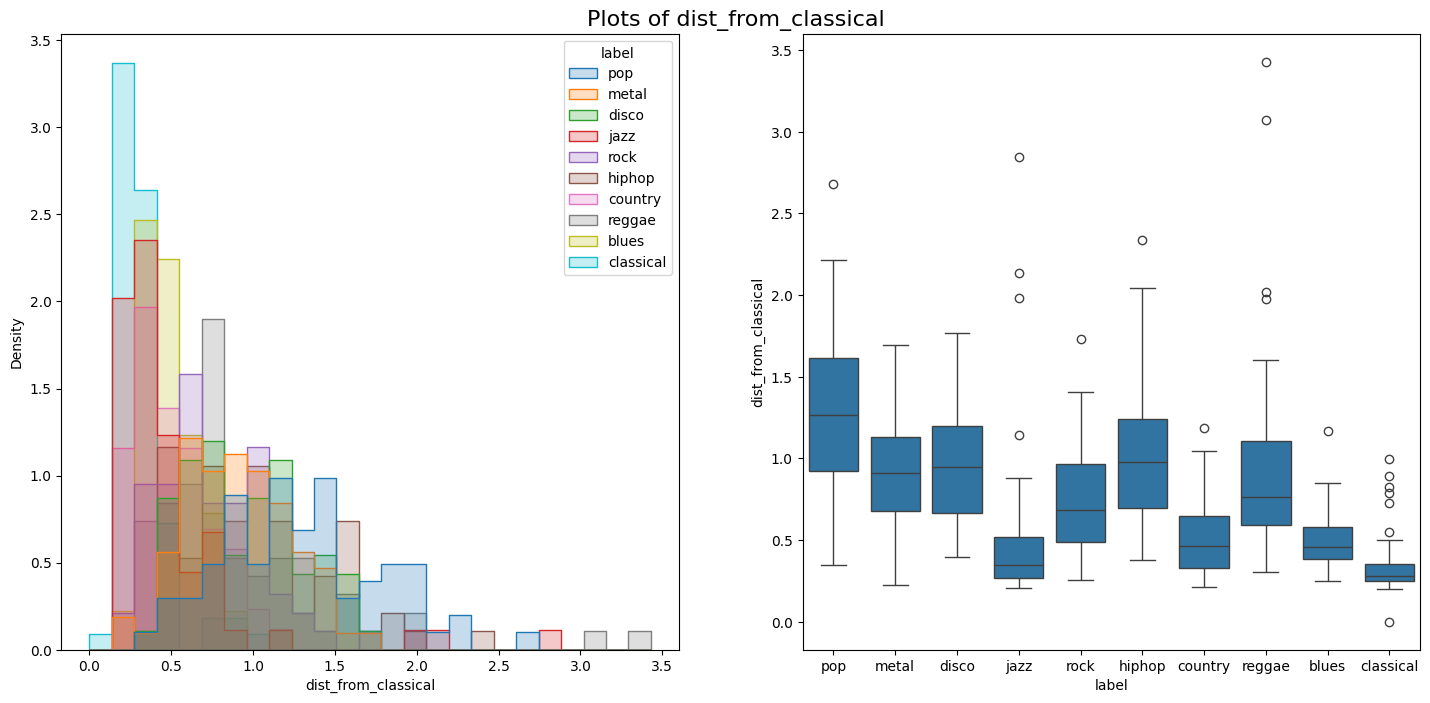

<Figure size 900x600 with 0 Axes>

<Figure size 900x600 with 0 Axes>

In [16]:
plot_box_hist('dist_from_classical')

# Evaluation

In [10]:
from sklearn.svm import SVC
from model_evaluation import EvalConfig, EvalModel
from sklearn import svm
from sklearn.svm import LinearSVC
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

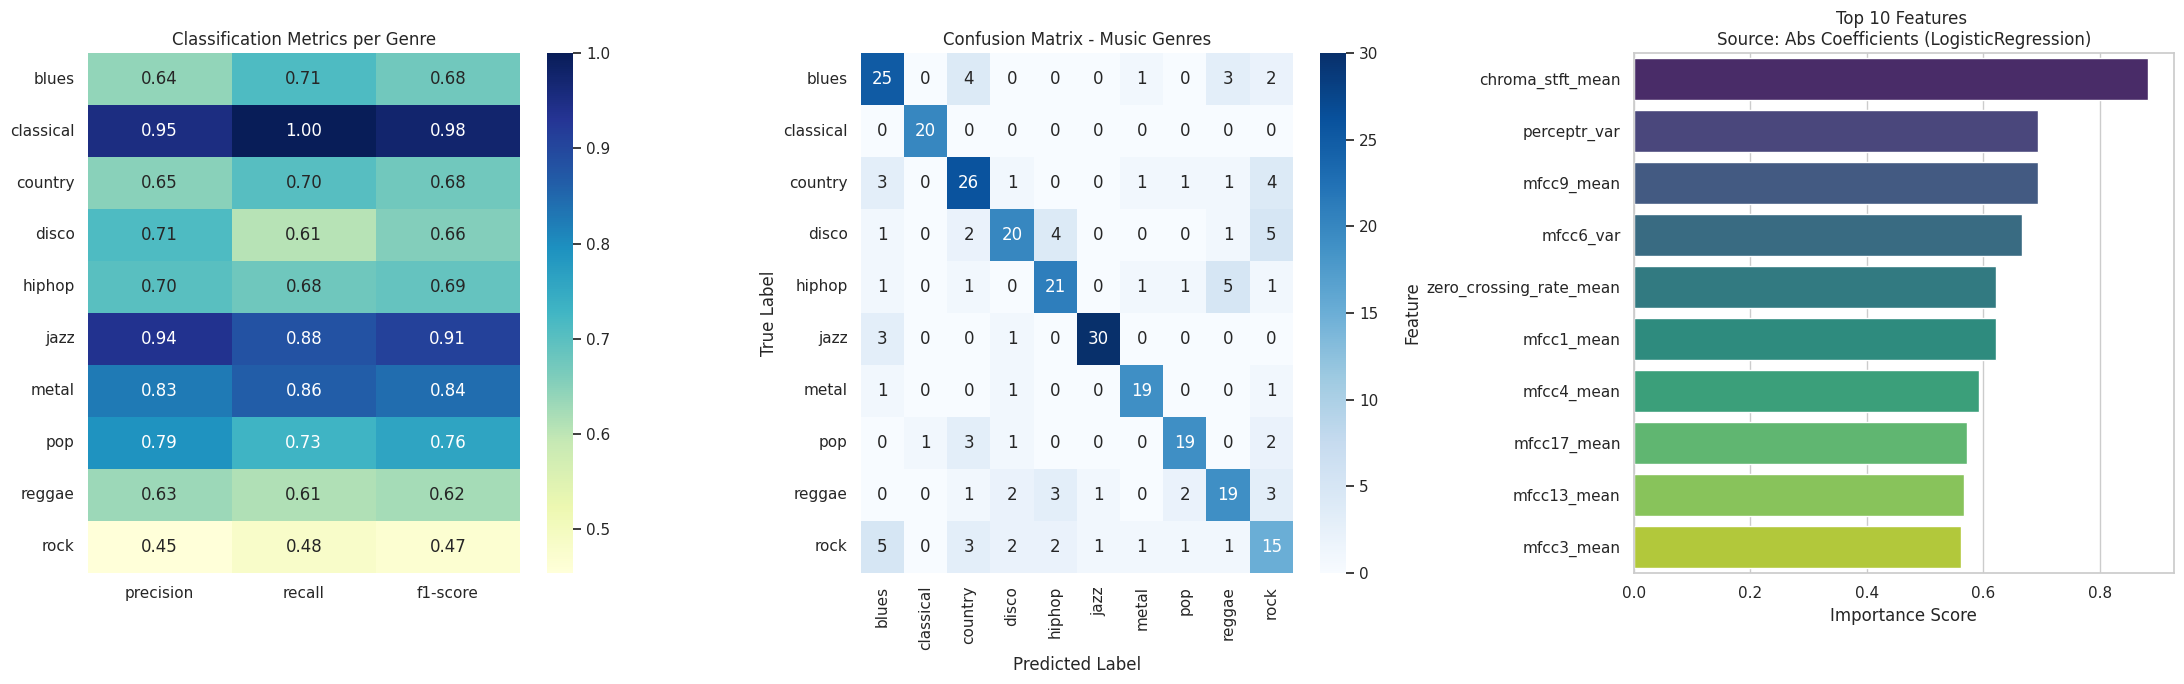

0.7133333333333334


In [11]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ('LogReg', LogisticRegression(random_state=42, C=1.0))
])

config = EvalConfig(
    train_path="Data/DTWFeatures/baseline_train.csv",
    test_path="Data/DTWFeatures/baseline_test.csv",
    pipeline=pipeline,
    drop_cols=['filename', 'length', 'label'],
    target_col = "label"
)

evalModel = EvalModel(config)
res = evalModel.evaluate()
plot = evalModel.plot_eval()
acc = res['report']['accuracy']
print(acc)

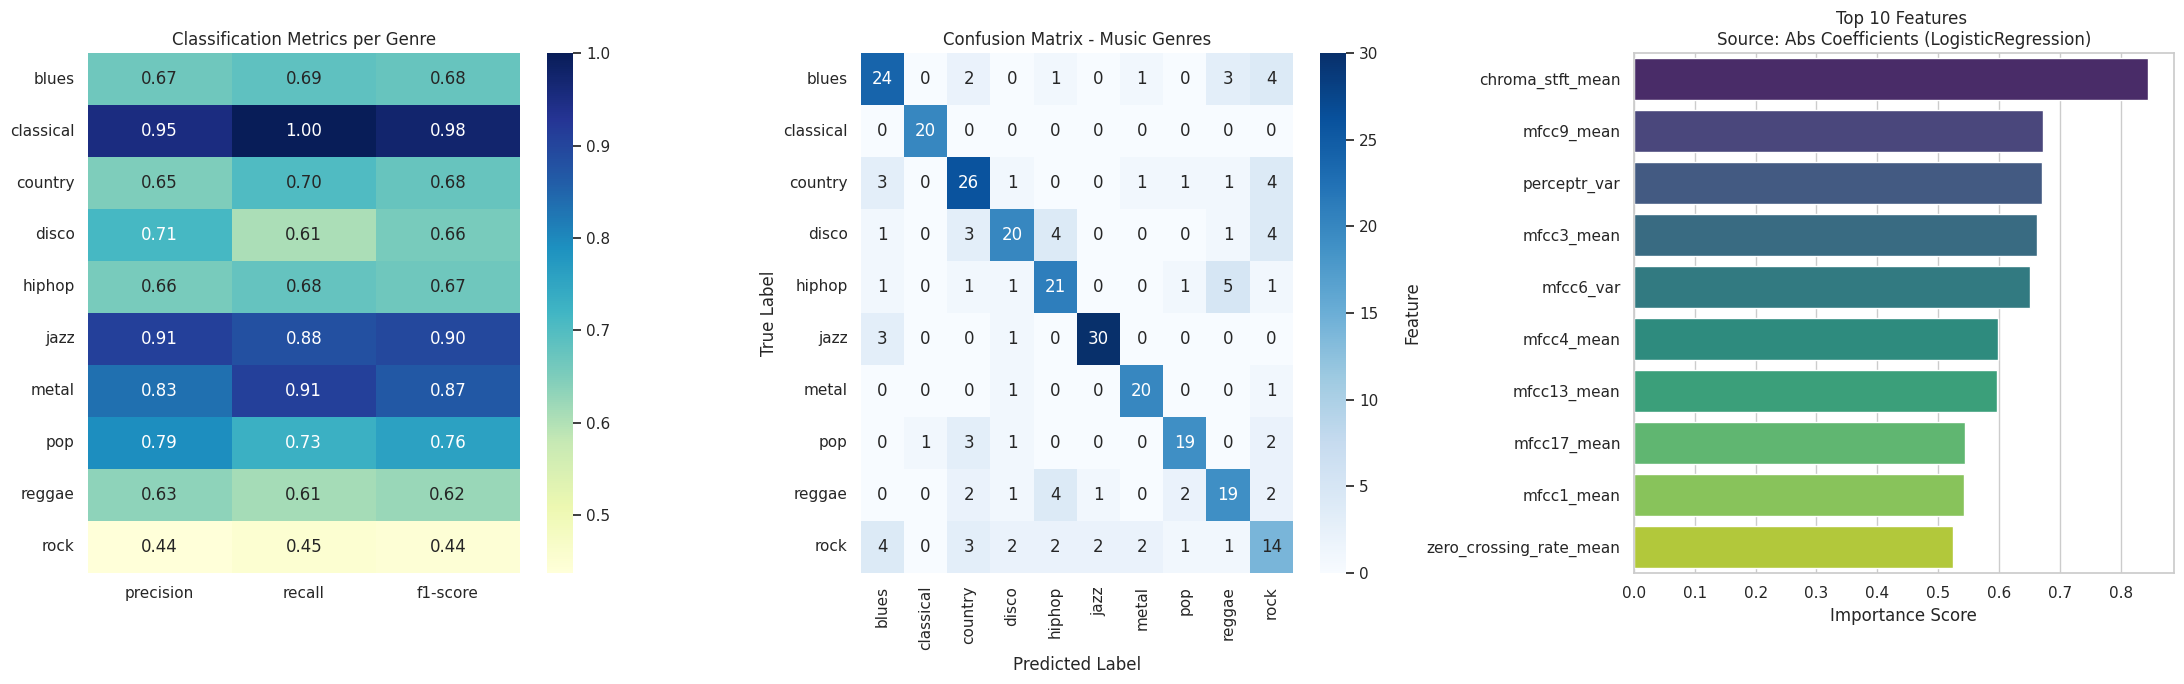

0.71


In [12]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ('LogReg', LogisticRegression(random_state=42, C=1.0))
])

config = EvalConfig(
    train_path="Data/DTWFeatures/dtw_train.csv",
    test_path="Data/DTWFeatures/dtw_test.csv",
    pipeline=pipeline,
    drop_cols=['filename', 'length', 'label'],
    target_col = "label"
)

evalModel = EvalModel(config)
res = evalModel.evaluate()
plot = evalModel.plot_eval()
acc = res['report']['accuracy']
print(acc)

In [13]:
from sklearn.neighbors import KNeighborsClassifier

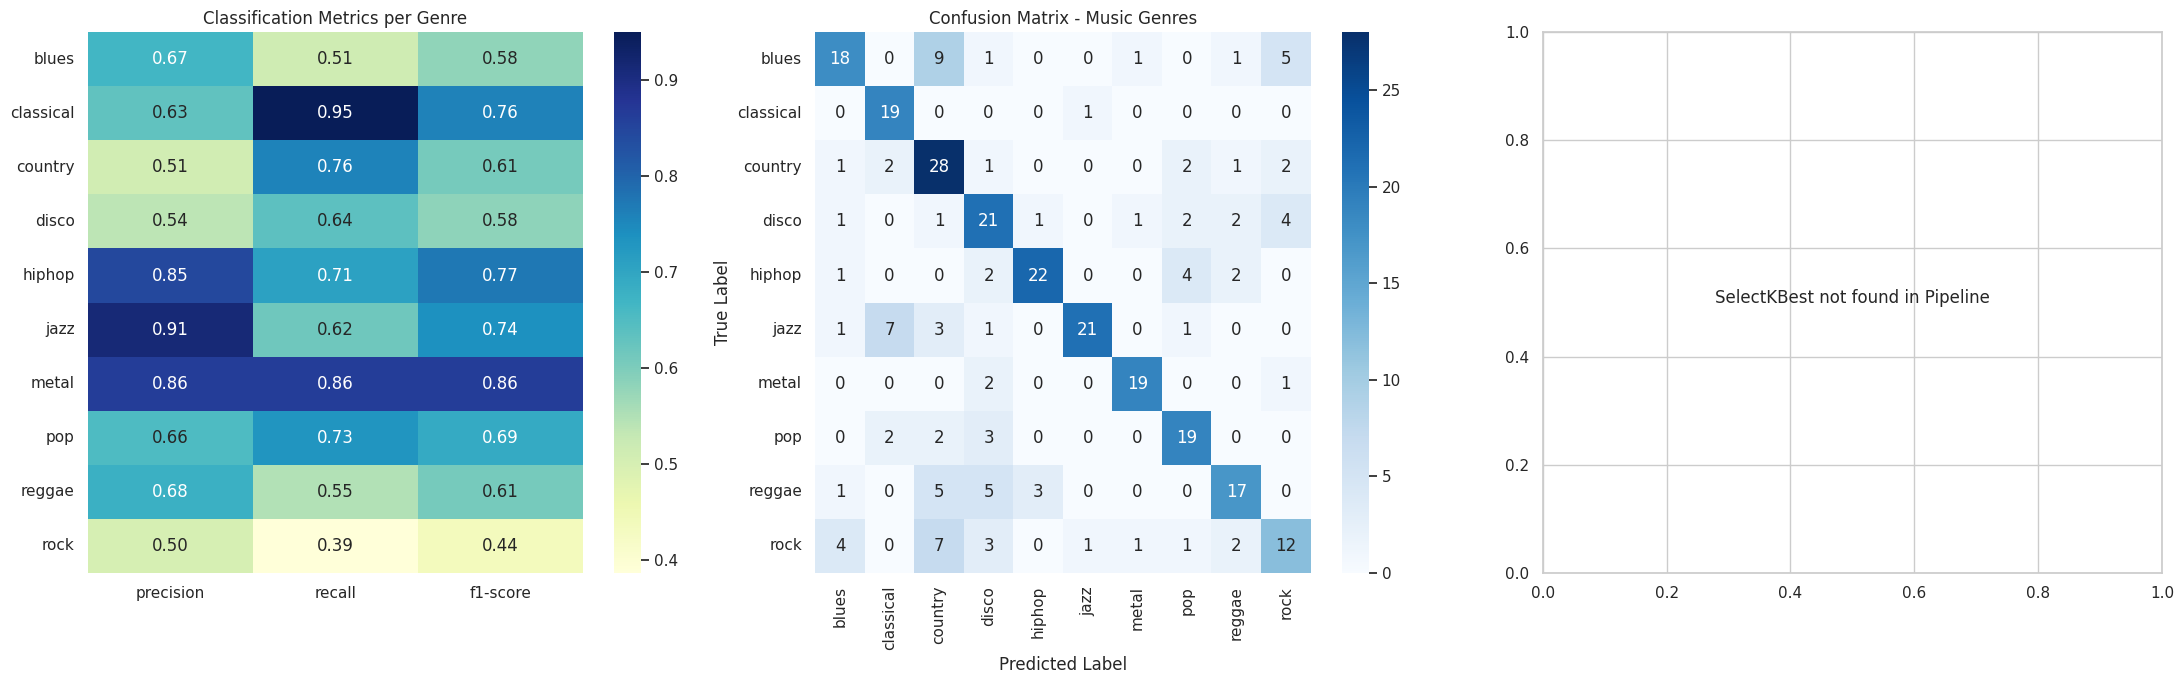

0.6533333333333333


In [21]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=9))
])

config = EvalConfig(
    train_path="Data/DTWFeatures/baseline_train.csv",
    test_path="Data/DTWFeatures/baseline_test.csv",
    pipeline=pipeline,
    drop_cols=['filename', 'length', 'label'],
    target_col = "label"
)

evalModel = EvalModel(config)
res = evalModel.evaluate()
plot = evalModel.plot_eval()
acc = res['report']['accuracy']
print(acc)

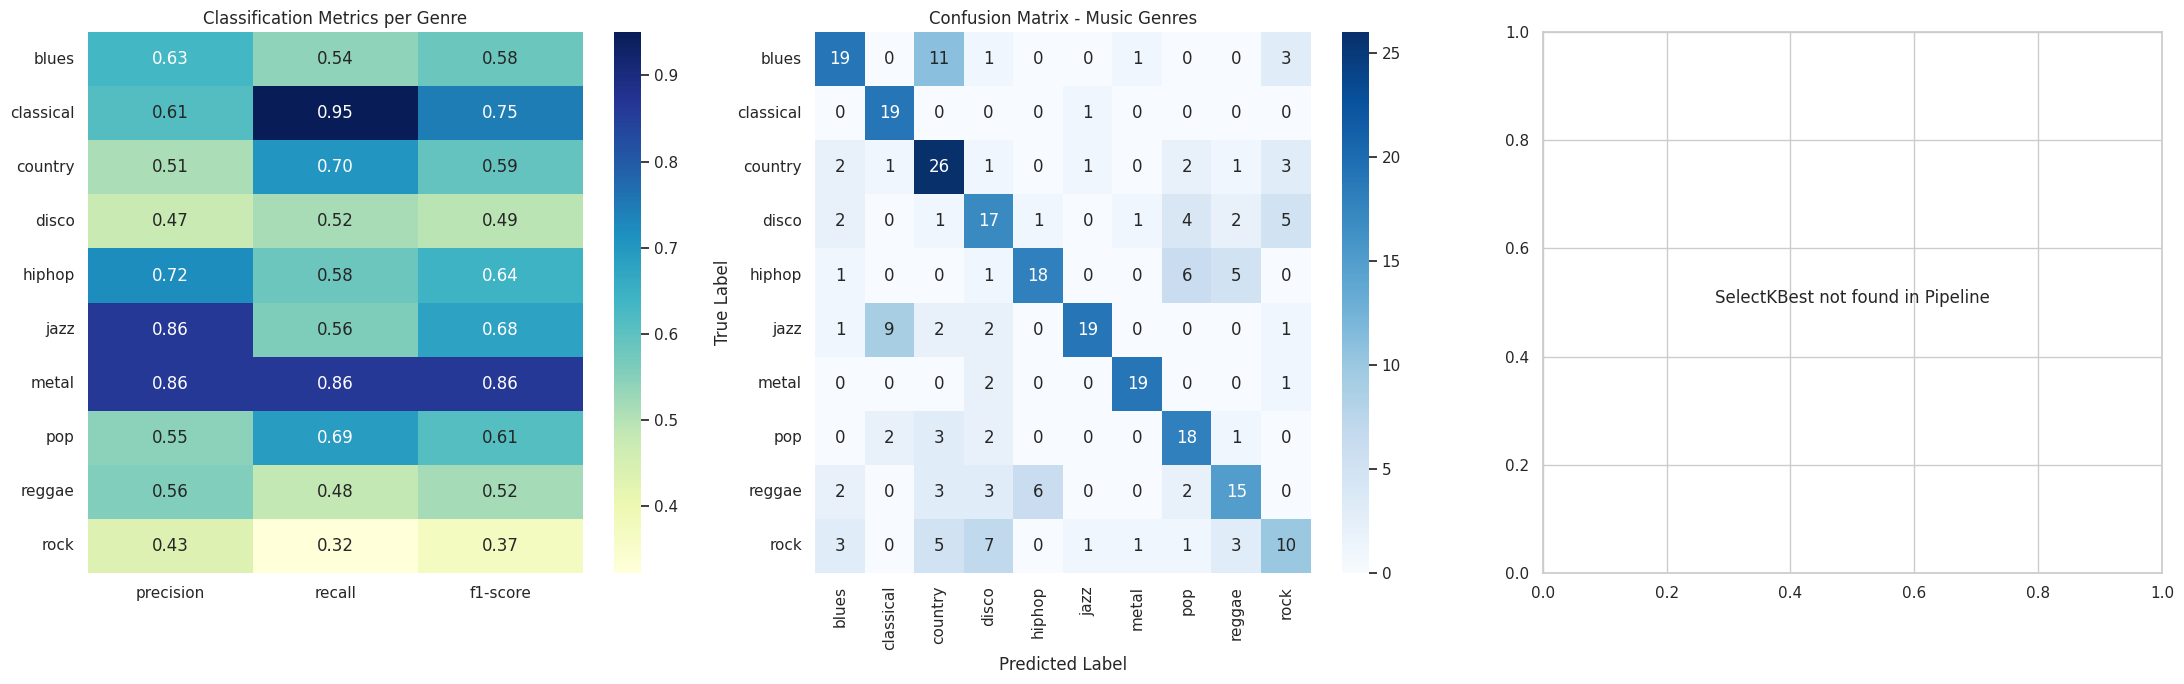

0.6


In [22]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=9))
])

config = EvalConfig(
    train_path="Data/DTWFeatures/dtw_train.csv",
    test_path="Data/DTWFeatures/dtw_test.csv",
    pipeline=pipeline,
    drop_cols=['filename', 'length', 'label'],
    target_col = "label"
)

evalModel = EvalModel(config)
res = evalModel.evaluate()
plot = evalModel.plot_eval()
acc = res['report']['accuracy']
print(acc)